<a href="https://colab.research.google.com/github/MdShajalalsojib/Machine-Learning-Lab/blob/main/K_Means_%2B_Elbow_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv('income.csv')

In [3]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [4]:
df.shape

(22, 3)

In [5]:
df.head(20)

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [7]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [8]:
df['Income($)']

,Income($)
0,70000
1,90000
2,61000
3,60000
4,150000
5,155000
6,160000
7,162000
8,156000
9,130000


In [9]:
df[['Name']]

,Name
0,Rob
1,Michael
2,Mohan
3,Ismail
4,Kory
5,Gautam
6,David
7,Andrea
8,Brad
9,Angelina


In [10]:
df['Age'].head()

,Age
0,27
1,29
2,29
3,28
4,42


In [11]:
df.sort_values(by='Age', ascending=False)

,Name,Age,Income($)
18,Nick,43,64000
4,Kory,42,150000
20,Sid,41,82000
17,Priyanka,41,63000
6,David,41,160000
16,Dipika,40,65000
5,Gautam,39,155000
19,Alia,39,80000
21,Abdul,39,58000
7,Andrea,38,162000


In [14]:
df.sort_values(by='Income($)', ascending=False)


,Name,Age,Income($)
7,Andrea,38,162000
6,David,41,160000
8,Brad,36,156000
5,Gautam,39,155000
4,Kory,42,150000
10,Donald,37,137000
9,Angelina,35,130000
1,Michael,29,90000
20,Sid,41,82000
19,Alia,39,80000


# Exploratory Data Analysis

In [15]:
df.drop('Name',axis=1,inplace=True)

In [16]:
df.head()

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


In [17]:
df.isnull().sum()

,0
Age,0
Income($),0


# Preprocessing

In [18]:
# normalization
df = (df-df.min())/(df.max()-df.min())

# Visualization

In [19]:
import matplotlib.pyplot as plt

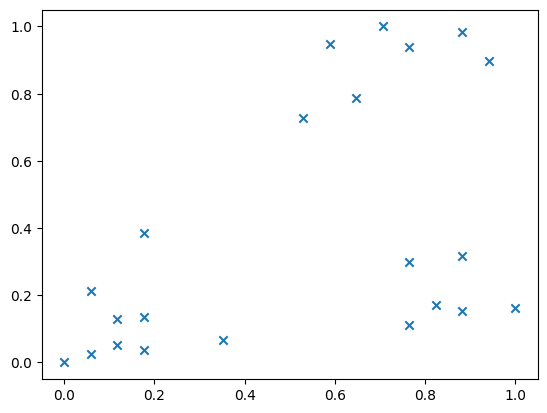

In [20]:
plt.scatter(df['Age'],df['Income($)'],marker='x')
plt.show()

# K-Means Clustering

In [21]:
from sklearn.cluster import KMeans

In [22]:
km = KMeans(n_clusters=3, random_state=81)

In [ ]:
# km.fit(df)
# km.predict(df)

In [23]:
cluster_label = km.fit_predict(df)

In [24]:
df['cluster'] = cluster_label

In [25]:
df

,Age,Income($),cluster
0,0.058824,0.213675,1
1,0.176471,0.384615,1
2,0.176471,0.136752,1
3,0.117647,0.128205,1
4,0.941176,0.897436,0
5,0.764706,0.940171,0
6,0.882353,0.982906,0
7,0.705882,1.000000,0
8,0.588235,0.948718,0
9,0.529412,0.726496,0


In [26]:
df_0 = df[df['cluster']==0]
df_1 = df[df['cluster']==1]
df_2 = df[df['cluster']==2]

In [27]:
km_center = km.cluster_centers_

In [28]:
print(km_center[0])
print(km_center[1])
print(km_center[2])

print(km_center[:,0])
print(km_center[:,1])

[0.72268908 0.8974359 ]
[0.1372549  0.11633428]
[0.85294118 0.2022792 ]
[0.72268908 0.1372549  0.85294118]
[0.8974359  0.11633428 0.2022792 ]


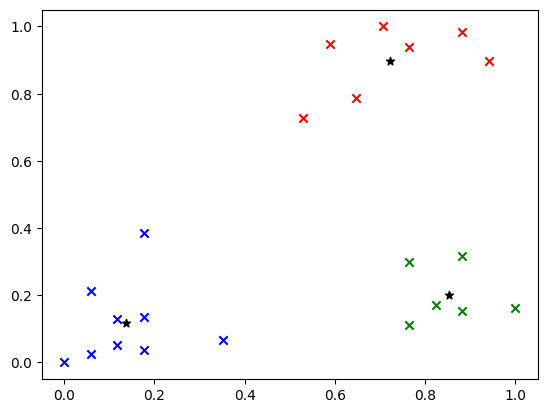

In [29]:
plt.scatter(df_0['Age'],df_0['Income($)'], marker='x', color='red')
plt.scatter(df_1['Age'],df_1['Income($)'], marker='x', color='blue')
plt.scatter(df_2['Age'],df_2['Income($)'], marker='x', color='green')
plt.scatter(km_center[:,0],km_center[:,1], marker='*', color='black')

In [30]:
km.inertia_ # k = 3

0.4750783498553095

#Elbow Method

In [31]:
sse = []

for k in range(1,10):
    km = KMeans(n_clusters=k)
    km.fit_predict(df[['Age','Income($)']])
    sse.append(km.inertia_)

Text(0.5, 1.0, 'Elbow Method Plotting')

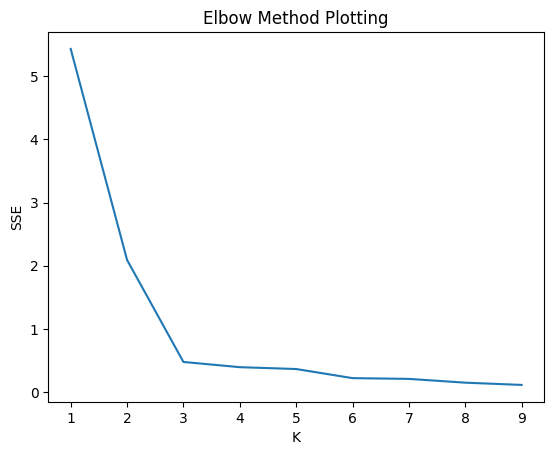

In [32]:
# plot the elbow
plt.plot(range(1,10), sse)
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Method Plotting')